# Physical Activity Assignment

Lien : [GitHub](https://github.com/sarah-mussotte/Physical-activity-00-Project)

Membres de l'équipe : Sarah MUSSOTTE, TaniaFar, tom22121 

## Bibliothèques 

On importe les bibliothèques dont on aura besoin. Nous utilisons "numpy" pour effectuer les calculs numériques, "pandas" pour charger et manipuler les données de l'accéléromètre, et "matplotlib" pour représenter graphiquement les résultats.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des données

Le fichier "0_z.csv" contient les données brutes enregistrées par l'accéléromètre Axivity AX3.
Les 4 colonnes correspondent au temps t en secondes et aux accélérations x, y et z exprimées en g.

On charge le fichier avec pandas afin de pouvoir facilement manipuler et analyser les données.

In [19]:
def load_data(path):
    """Charge les données brutes de l'accéléromètre."""
    return pd.read_csv(path, comment="#")

data = load_data("0_z.csv")

data.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Calculer l'ENMO

L'ENMO (Euclidean Norm Minus One) permet de combiner les accélérations mesurées selon les trois axes en une seule valeur.

On calcule d'abord la norme du vecteur d'accélération :

$$
\sqrt{x^2 + y^2 + z^2}
$$

Puis on soustrait 1 g, qui correspond à l'accélération due à la gravité :

$$
ENMO = \sqrt{x^2 + y^2 + z^2} - 1
$$

Cette opération permet d'obtenir une mesure représentant les variations d'accélération liées au mouvement.

In [20]:
def calculate_enmo(df):
    """Calcule l'ENMO à partir des trois axes x, y et z."""
    df = df.copy()
    df["enmo"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2) - 1
    return df

data = calculate_enmo(data)

data.head()

,t,x,y,z,enmo
0,0.00,-0.0938,-0.0156,0.9531,-0.042168
1,0.02,-0.0938,-0.0156,0.9531,-0.042168
2,0.04,-0.0938,-0.0156,0.9531,-0.042168
3,0.06,-0.0938,-0.0156,0.9531,-0.042168
4,0.08,-0.0938,-0.0156,0.9531,-0.042168


## Intégration de l'ENMO sur des epochs de 60s

Nous calculons d'abord la fréquence d'échantillonnage à partir de l'écart de temps entre deux mesures successives.

La fréquence d'échantillonnage correspond au nombre de mesures enregistrées par seconde. Elle est calculée avec la formule :

$$
f_s = \frac{1}{t_1-t_0}
$$

Dans notre jeu de données, les mesures sont espacées de 0,02 seconde, ce qui donne une fréquence de 50 Hz. Cela signifie que l'accéléromètre enregistre 50 mesures par seconde.

Cette valeur est nécessaire pour déterminer le nombre d'échantillons correspondant à une epoch de 60 secondes.

In [28]:
fs = 1 / (data["t"].iloc[1] - data["t"].iloc[0])

print("Fréquence d'échantillonnage :", fs, "Hz")

Fréquence d'échantillonnage : 50.0 Hz


Nous souhaitons maintenant regrouper les valeurs d'ENMO par intervalles de temps appelés « epochs ».

La fonction ci-dessous permet de réaliser cette opération pour une durée d'epoch donnée. Le nombre d'échantillons contenu dans une epoch est calculé à partir de la durée de l'epoch et de la fréquence d'échantillonnage.

Pour chaque epoch, les valeurs d'ENMO sont additionnées puis multipliées par la durée de l'epoch exprimée en minutes afin d'obtenir une valeur d'ENMO intégré en g.min.

La fonction retourne également le temps de début de chaque epoch afin de pouvoir positionner les résultats sur le graphique.

In [29]:
def integrate_enmo(df, epoch_seconds, fs):
    """Intègre l'ENMO sur des epochs de durée donnée."""
    
    samples_per_epoch = int(epoch_seconds * fs)
    n_epochs = len(df) // samples_per_epoch

    integrated = []
    start_times = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch

        epoch = df["enmo"].iloc[start:end]

        integrated_value = np.sum(epoch) * (epoch_seconds / 60)

        integrated.append(integrated_value)
        start_times.append(df["t"].iloc[start])

    return pd.DataFrame({
        "start": start_times,
        "integrated_enmo": integrated })

Avec une fréquence d'échantillonnage de 50 Hz, une epoch de 60 secondes contient :

$$
60 \times 50 = 3000
$$

échantillons.

Nous appliquons donc la fonction d'intégration au signal ENMO avec une durée d'epoch de 60 secondes.

In [30]:
epoch_60 = 60

epochs_60 = integrate_enmo(data, epoch_60, fs)

epochs_60.head()

,start,integrated_enmo
0,0.0,-135.986535
1,60.0,-135.529833
2,120.0,-134.928962
3,180.0,-135.749533
4,240.0,976.726915


On vérifie que le signal a bien été découpé en epochs de 60 secondes.

À 50 Hz, chaque epoch doit contenir 3000 échantillons. On vérifie aussi le nombre total d'epochs obtenues afin de nous assurer que le découpage des données est correct.

In [31]:
print("Durée d'un epoch :", epoch_60, "secondes")
print("Nombre d'échantillons par epoch :", int(epoch_60 * fs))
print("Nombre d'epochs :", len(epochs_60))

Durée d'un epoch : 60 secondes
Nombre d'échantillons par epoch : 3000
Nombre d'epochs : 7


## Visualisation des résultats

On créée maintenant une fonction permettant de représenter les résultats.

Le graphique est composé de deux parties. En haut, les barres représentent l'ENMO intégré pour chaque epoch de 60 secondes. En bas, le signal ENMO brut est représenté en fonction du temps.

Les deux graphiques partagent le même axe temporel afin de pouvoir comparer les valeurs intégrées avec le signal original. La largeur de chaque barre correspond à la durée d'une epoch.

Cette représentation permet de voir comment l'activité enregistrée par l'accéléromètre est résumée lorsque le signal est regroupé par intervalles de 60 secondes.

In [32]:
def plot_enmo_epoch(df, epoch_seconds, fs):
    """Trace l'ENMO intégré et le signal ENMO brut."""
    
    epochs = integrate_enmo(df, epoch_seconds, fs)

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(10, 6))

    # Graphique de l'ENMO intégré
    epoch_times = epochs["start"] / 60
    epoch_width = epoch_seconds / 60

    ax1.bar(
        epoch_times,
        epochs["integrated_enmo"],
        width=epoch_width * 0.9,
        align="edge",
        color="grey",
        alpha=0.7)

    ax1.set_title(f"ENMO integrated over {float(epoch_seconds)} s intervals")
    ax1.set_ylabel("Integrated ENMO (g.min)")

    # Signal ENMO brut
    ax2.plot(
        df["t"] / 60,
        df["enmo"],
        alpha=0.5 )

    ax2.set_title("ENMO over Time")
    ax2.set_xlabel("Time (minutes)")
    ax2.set_ylabel("ENMO (g)")

    plt.tight_layout()
    plt.show()

Nous appliquons la fonction de visualisation avec une durée d'epoch de 60 secondes afin d'obtenir le graphique demandé dans la consigne.

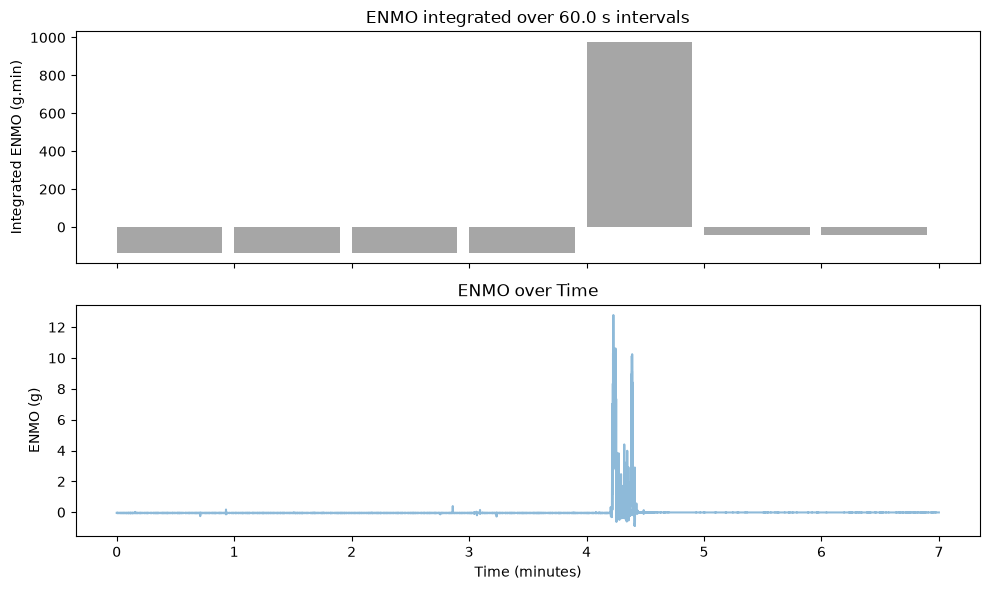

In [33]:
plot_enmo_epoch(data, 60, fs)

## Prompt IA (Mussotte Sarah)

L'assistance par IA a été utilisée pour clarifier les principales étapes méthodologiques de l'analyse. Les suggestions obtenues ont été vérifiées puis adaptées avant d'être intégrées au notebook.

### Prompt 1

**« Quelle est la fréquence d'échantillonnage de données d'accéléromètre lorsque deux mesures successives sont espacées de 0,02 seconde ? »**

**Vérification et modification :**

Le calcul proposé a été vérifié et utilisé pour déterminer la fréquence d'échantillonnage du jeu de données. Le résultat obtenu est de 50 Hz, ce qui signifie que 50 mesures sont enregistrées chaque seconde.

### Prompt 2

**« Comment intégrer l'ENMO sur des epochs de 60 secondes lorsque la fréquence d'échantillonnage est de 50 Hz ? »**

**Vérification et modification :**

La méthode proposée a été vérifiée puis adaptée à la structure de notre notebook. J'ai vérifié qu'une epoch de 60 secondes contient 3000 échantillons à 50 Hz. L'intégration a ensuite été calculée pour chaque epoch de 60 secondes.

### Prompt 3

**« Comment représenter graphiquement l'ENMO intégré sur des epochs de 60 secondes avec le signal ENMO brut ? »**

**Vérification et modification :**

La méthode de représentation proposée a été adaptée afin de correspondre aux graphiques de référence fournis dans la consigne. Les valeurs d'ENMO intégré sont représentées sous forme de barres dans le graphique supérieur, tandis que le signal ENMO brut est représenté dans le graphique inférieur. Les deux graphiques partagent le même axe temporel afin de faciliter la comparaison.

